In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
# import seaborn as sns
from pathlib import Path

# coastsat modules
sys.path.insert(0, os.pardir)
from coastsat import SDS_download, SDS_preprocess, SDS_shoreline, SDS_tools, SDS_classify, SDS_transects
from osgeo import gdal
gdal.UseExceptions()

from indices import *
from thresholding import *
import wv_utils as wv
import wv_eval
import wv_eval_plotting as wvep
import modified_coastsat
import metrics as m
import local_sl_extraction as lse
import spectral_unmixing as su
import degradation as deg

In [17]:
# paths
base_dir = "C:\\Users\\avanever\\Documents\\Imagery Datasets\\WV3 SWIR\\W075_N10\\20200104T15431"
swir_fn = os.path.join(base_dir, "20JAN04154316-A3DS-015384188020_01_P001.TIF")
ms_fn = os.path.join(base_dir, "20JAN04154317-M3DS-015384188010_01_P001.TIF")
pan_fn = os.path.join(base_dir, "20JAN04154317-P3DS-015384188010_01_P001.TIF")
ref_sl_path = Path(r"C:\Users\avanever\Documents\CoastSatProject\Experiments\data\colombia_hand_digitized\colombia_hand_shoreline.shp")
transect_path = Path(r"C:\Users\avanever\Documents\CoastSatProject\Experiments\data\transects\colombia_transects.geojson")
ref_sl_path = Path(r"C:\Users\avanever\Documents\CoastSatProject\Experiments\data\colombia_hand_digitized\colombia_hand_shoreline.shp")

In [44]:
sitename = "Colombia"
sim_sat = "S2"
image_epsg = 32618

data = wv.init(sim_sat, base_dir, ref_sl_path, transect_path, image_epsg)
sim_bands, georef, im_nodata, cloud_mask, transects, transects_pix, ref_sl_points, ref_sl_points_pxl, sds_settings, collider_settings, sds_data = data

86 transects have been loaded 
coordinates are in epsg:4326


In [4]:
index_functions = [
    mndwi,
    ndwi,
    awei_ns,
    awei_sh,
    scowi,
    wi2015,
    andwi,
    wri,
    ewi,
    nwi,
    wi2019,
    tct_wetness,
    ddwi,
    ensemble1,
    ensemble2,
    "spectral_unmixing"
]
threshold_functions = [
    otsu,
    local_min_otsu
]
ensemble_idx_funcs = index_functions[:-3] # all but the ensemble indices and spectral unmixing

## Save Plots

In [21]:
root_output_dir = os.path.join(r"C:\Users\avanever\Documents\CoastSatProject\Experiments\wv3", sitename)

sitename = "Colombia"
sim_sats = ["L8", "L9", "S2"]
image_epsg = 32618

for sim_sat in sim_sats:
    output_dir = os.path.join(root_output_dir, sim_sat)
    os.makedirs(output_dir, exist_ok=True)

    data = wv.init(sim_sat, base_dir, ref_sl_path, transect_path, image_epsg)
    sim_bands, georef, im_nodata, cloud_mask, transects, transects_pix, ref_sl_points, ref_sl_points_pxl, sds_settings, collider_settings, sds_data = data

    """ Run All Methods"""
    shoreline_metric, transect_metric, methods, info = wv_eval.evaluate_methods(
        index_functions, threshold_functions, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs
    )
    entries, outlier_idx = wv_eval.organize_metrics(shoreline_metric, transect_metric, methods)

    sl_values = np.nanmin(shoreline_metric, axis=0)
    best_per_point_idx = np.nanargmin(shoreline_metric, axis=0)

    best_per_transect_idx = np.nanargmin(np.abs(transect_metric), axis=0)
    t_idx = np.arange(transect_metric.shape[1])
    t_values = np.abs(transect_metric[best_per_transect_idx, t_idx])

    # Save metrics for each method to text file
    with open(os.path.join(output_dir, "metrics.txt"), 'w') as f:
        wv_eval.print_metrics(entries, sort_variable="sl_mean", file=f)
        print("\n")
        wv_eval.print_metrics(entries, sort_variable="t_mae", file=f)
        print("\n")
        wv_eval.print_metrics(entries, sort_variable="sl_n_outliers", file=f)
        print("\n")
        wv_eval.print_metrics(entries, sort_variable="t_mean", file=f)

    # "Best per" plots
    fig = wvep.plot_best_score_per_point(sl_values, ref_sl_points_pxl, sim_bands[:,:,[2, 1, 0]], sitename, sim_sat)
    plt.savefig(os.path.join(output_dir, sitename + "_" + sim_sat + "_best_score_per_point"))
    plt.close(fig)
    fig = wvep.plot_best_method_per_point(best_per_point_idx, methods, ref_sl_points_pxl, sim_bands[:,:,[2, 1, 0]], sitename, sim_sat)
    plt.savefig(os.path.join(output_dir, sitename + "_" + sim_sat + "_best_method_per_point"))
    plt.close(fig)
    fig = wvep.plot_best_method_counts(best_per_point_idx, methods, "Shoreline Metric Best Method Percentages", pie_instead=True)
    plt.savefig(os.path.join(output_dir, sitename + "_" + sim_sat + "_best_sl_method_pie"))
    plt.close(fig)
    fig = wvep.plot_best_score_per_transect(t_values, transects_pix, ref_sl_points_pxl, sim_bands[:,:,[2, 1, 0]], sitename, sim_sat)
    plt.savefig(os.path.join(output_dir, sitename + "_" + sim_sat + "_best_score_per_transect"))
    plt.close(fig)
    fig = wvep.plot_best_method_per_transect(best_per_transect_idx, methods, transects_pix, ref_sl_points_pxl, sim_bands[:,:,[2, 1, 0]], sitename, sim_sat)
    plt.savefig(os.path.join(output_dir, sitename + "_" + sim_sat + "_best_method_per_transect"))
    plt.close(fig)
    fig = wvep.plot_best_method_counts(best_per_transect_idx, methods, "Transect Metric Best Method Percentages", pie_instead=True)
    plt.savefig(os.path.join(output_dir, sitename + "_" + sim_sat + "_best_transect_method_pie"))
    plt.close(fig)

    # Boxplots
    title = f"{sitename}_{sim_sat}: Shoreline Metric Boxplot"
    fig, ax = wvep.violin_plots(shoreline_metric, methods, title, ylim=(0, 25), outlier_idx=outlier_idx, box_instead=True, sort_methods=True)
    plt.savefig(os.path.join(output_dir, sitename + "_" + sim_sat + "shoreline_metric_boxplot"))
    plt.close(fig)
    title = f"{sitename}_{sim_sat}: Transect Metric Error Boxplot"
    fig, ax = wvep.violin_plots(transect_metric, methods, title, box_instead=True, sort_methods=True)
    ax.axhline(0)
    plt.savefig(os.path.join(output_dir, sitename + "_" + sim_sat + "transect_error_boxplot"))
    plt.close(fig)
    title = f"{sitename}_{sim_sat}: Transect Metric MAE Boxplot"
    fig, ax = wvep.violin_plots(np.abs(transect_metric), methods, title, box_instead=True, sort_methods=True)
    plt.savefig(os.path.join(output_dir, sitename + "_" + sim_sat + "transect_MAE_boxplot"))
    plt.close(fig)

86 transects have been loaded 
coordinates are in epsg:4326


32it [00:16,  1.93it/s]








86 transects have been loaded 
coordinates are in epsg:4326


32it [00:16,  1.90it/s]








86 transects have been loaded 
coordinates are in epsg:4326


32it [00:16,  1.90it/s]


## Degradation

Using Gaussian kernel for degradation (with FWHM modified scale)

L5:
- Degrade to 30m
- Bilinear interpolation to 15m
- SNR Match

L7:
- Degrade ms to 30m and pan to 15m
- Pansharpening (still bands 0, 1, 2 cuz that's what's covered by WV3)
- SNR Match

L8 and L9:
- Degrade ms to 30m and pan to 15m
- Pansharpening (bands 0, 1, 2)

S2:
- Degrade ms to 10m and swir to 20m
- Bilinear interpolation to 10m

In [4]:
l8_path = r"C:\Users\avanever\Documents\CoastSatProject\Experiments\data\colombia\L8\ms\2020-01-09-15-17-31_L8_009053_colombia_ms.tif"
l9_path = r"C:\Users\avanever\Documents\CoastSatProject\Experiments\data\colombia\L9\ms\2021-12-28-15-23-48_L9_010053_colombia_ms.tif"
s2_path = r"C:\Users\avanever\Documents\CoastSatProject\Experiments\data\colombia\S2\2020-01-02-15-40-10_S2_18PVS_colombia.tif"
l8_bands = wv.load_sim_tif(l8_path)
l9_bands = wv.load_sim_tif(l9_path)
s2_bands = wv.load_sim_tif(s2_path)

im_dir = r"C:\Users\avanever\Documents\Imagery Datasets\WV3 SWIR\W075_N10\20200104T15431\gaussian_deg\\"
out_fns = {sat : im_dir + sat + "_sim.tif" for sat in ["L8", "L9", "S2"]}
ref_fn = [l8_path, l9_path, s2_path]

deg_30_fn = im_dir + "deg_30.tif"
warp_fn = im_dir + "ms_interp_15.tif"
ps_fn = im_dir + "ps_15.tif"
swir_warp_fn = im_dir + "swir_interp_10.tif"
deg_20_fn = im_dir + "swir_deg_15.tif"

In [5]:
# get source bands coregistered and in 3.7m (swir) resolution
swir_fn, pan_fn, ms_fn = wv.coreg_tifs(base_dir, gdal.GRA_Bilinear, ref_idx=0) # use swir as reference for coreg
swir_bands = wv.load_tif(swir_fn, is_swir=True)[:,:,[1, 5]]
ms_bands = wv.load_tif(ms_fn)[:,:,[1, 2, 4, 6]]
pan_band = wv.load_tif(pan_fn)
ms_ds = gdal.Open(ms_fn)
in_gt, in_proj = ms_ds.GetGeoTransform(), ms_ds.GetProjection()
ms_ds = None
source_bands = np.concatenate([ms_bands, swir_bands], axis=2)
source_res = 3.7
kernel_radius = 12

""" Gaussian Kernel Degradation """
ms_30_output, ms_30_adj_res, _ = deg.kernel_deg(source_bands, source_res, kernel_radius, target_res=30) # all Landsat
pan_output, pan_adj_res, _ = deg.kernel_deg(pan_band, source_res, kernel_radius, target_res=15) # L7, L8, L9
ms_10_output, ms_10_adj_res, _ = deg.kernel_deg(ms_bands, source_res, kernel_radius, target_res=10) # S2
swir_output, swir_adj_res, _ = deg.kernel_deg(swir_bands, source_res, kernel_radius, target_res=ms_10_adj_res * 2) # S2

""" Pansharpening (L7, L8, L9) """
deg.save_gaus_deg_tif(deg_30_fn, ms_30_output, source_res, kernel_radius, ms_30_adj_res, in_proj, in_gt)
bounds = deg.calc_bounds(source_res, kernel_radius, ms_30_adj_res, ms_30_output.shape, in_gt)
deg.double_resolution(warp_fn, deg_30_fn, ms_30_adj_res, bounds)
im_ms_ps = deg.pansharpen_gaussian_deg(warp_fn, pan_output)
deg.save_ps_tif(ps_fn, im_ms_ps, bounds, ms_30_adj_res, in_proj)

""" Double resolution swir 20m bands """
deg.save_gaus_deg_tif(deg_20_fn, swir_output, source_res, kernel_radius, swir_adj_res, in_proj, in_gt)
bounds = deg.calc_bounds(source_res, kernel_radius, swir_adj_res, swir_output.shape, in_gt)
deg.double_resolution(swir_warp_fn, deg_20_fn, swir_adj_res, bounds)
swir_10_output = wv.load_sim_tif(swir_warp_fn)
ms_10_output, swir_10_output = deg.normalize_im_dim([ms_10_output, swir_10_output])
deg_10_bands = np.concatenate([ms_10_output, swir_10_output], axis=2)

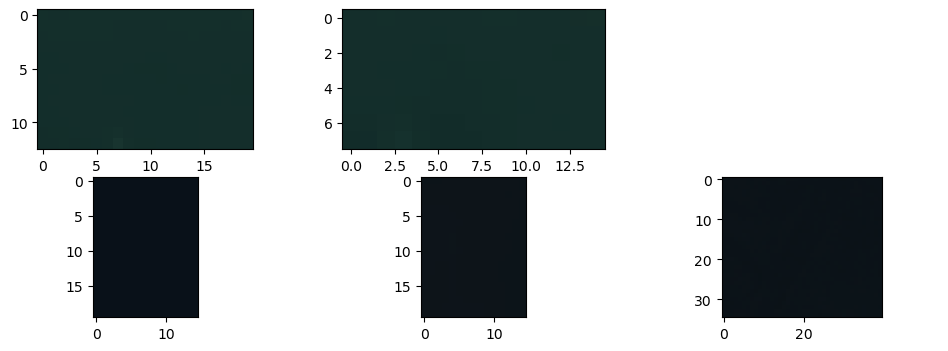

In [ ]:
""" Confirm Patches are good for SNR Matching"""
# Colombia
l8_patch, l9_patch, s2_patch = l8_bands[100:120,70:85], l9_bands[100:120,70:85], s2_bands[155:190,95:135]
patch_indices = {
    "S2" : {"r": (40,53), "c": (10,30)}, # gs_deg_10
    "L_PS" : {"r": (32,40), "c": (10,25)}, # gs_ps_15
}

p = patch_indices["S2"]
s2_sim_patch = deg_10_bands[p["r"][0]:p["r"][1], p["c"][0]:p["c"][1]]
p = patch_indices["L_PS"]
l_ps_sim_patch = im_ms_ps[p["r"][0]:p["r"][1], p["c"][0]:p["c"][1]]

fig, axs = plt.subplots(2, 3, figsize=(12, 4))
axs = axs.ravel()
axs[0].imshow(s2_sim_patch[:,:,[2,1,0]])
axs[1].imshow(l_ps_sim_patch[:,:,[2,1,0]])
axs[2].axis(False); # for L5

axs[3].imshow(l8_patch[:,:,[2,1,0]])
axs[4].imshow(l9_patch[:,:,[2,1,0]])
axs[5].imshow(s2_patch[:,:,[2,1,0]])

In [7]:
""" SNR Matching """
s2_snr, _, _ = deg.directional_semivariogram_snr(s2_patch, dir="row")
l8_snr, _, _ = deg.directional_semivariogram_snr(l8_patch, dir="row")
l9_snr, _, _ = deg.directional_semivariogram_snr(l9_patch, dir="row")

s2_sim_snr, _, _,  = deg.directional_semivariogram_snr(s2_sim_patch, dir="row")
l_ps_sim_snr, _, _,  = deg.directional_semivariogram_snr(l_ps_sim_patch, dir="row")

l8_sim = deg.match_snr(im_ms_ps, l_ps_sim_snr, l8_snr)
l9_sim = deg.match_snr(im_ms_ps, l_ps_sim_snr, l9_snr)
s2_sim = deg.match_snr(deg_10_bands, s2_sim_snr, s2_snr)

""" Save final simulation images"""
deg.save_gaus_deg_tif(out_fns["L8"], l8_sim, source_res, kernel_radius, pan_adj_res, in_proj, in_gt)
deg.save_gaus_deg_tif(out_fns["L9"], l9_sim, source_res, kernel_radius, pan_adj_res, in_proj, in_gt)
deg.save_gaus_deg_tif(out_fns["S2"], s2_sim, source_res, kernel_radius, ms_10_adj_res, in_proj, in_gt)

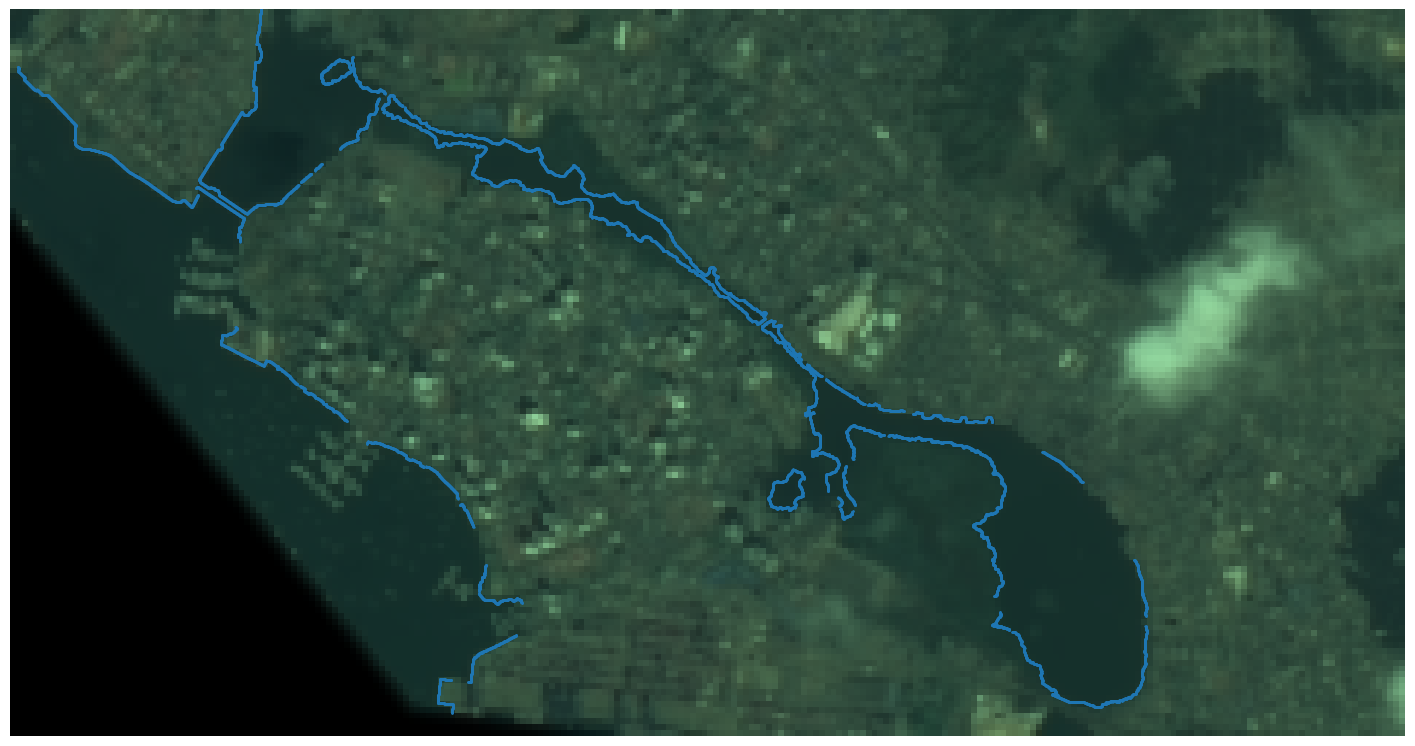

In [8]:
fn = out_fns["L9"]
bands = wv.load_sim_tif(fn)

gt = gdal.Open(fn).GetGeoTransform()
bands = wv.load_sim_tif(fn)
sl_px = SDS_tools.convert_world2pix(ref_sl_points, gt)

fig, ax = plt.subplots(figsize=(18, 10))
ax.scatter(sl_px[:,0], sl_px[:,1], s=0.5)
ax.imshow(bands[:,:,[2,1,0]])
ax.axis(False);

## Bests for Shoreline Metric (nearest point) and Transect Metric (median distance)

Best method changes so frequently picking a "best" method is very ambiguous (beyond looking at summary metrics)

Some areas are not extracted well by any methods (around clouds, certain edges)

In [45]:
shoreline_metric, transect_metric, methods, info = wv_eval.evaluate_methods(
    index_functions, threshold_functions, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs
)
entries, outlier_idx = wv_eval.organize_metrics(shoreline_metric, transect_metric, methods)

sl_values = np.nanmin(shoreline_metric, axis=0)
best_per_point_idx = np.nanargmin(shoreline_metric, axis=0)

best_per_transect_idx = np.nanargmin(np.abs(transect_metric), axis=0)
t_idx = np.arange(transect_metric.shape[1])
t_values = np.abs(transect_metric[best_per_transect_idx, t_idx])

32it [00:13,  2.45it/s]


In [46]:
wv_eval.print_metrics(entries, sort_variable="sl_mean")
print("\n")
wv_eval.print_metrics(entries, sort_variable="t_mae")
print("\n")
wv_eval.print_metrics(entries, sort_variable="sl_n_outliers")
print("\n")
wv_eval.print_metrics(entries, sort_variable="t_mean")

Sorted by sl_mean                   sl_mean      sl_mean_all  sl_std       sl_outlier     t_mean       t_std        t_mae       
spectral_unmixing__otsu:            4.783        8.351        13.374       1604           1.442        3.217        2.566       
ewi__otsu:                          4.863        10.335       18.628       1929           1.352        2.497        2.198       
ndwi__otsu:                         5.796        21.018       47.545       2610           -0.163       4.899        3.159       
ensemble1__otsu:                    6.051        22.889       46.776       3530           1.502        4.769        3.745       
ensemble2__otsu:                    6.066        22.231       45.834       3455           1.207        4.731        3.753       
andwi__otsu:                        6.590        23.266       46.358       3592           1.303        4.968        3.823       
ewi__local_min_otsu:                6.722        22.772       49.223       2901           2.576  

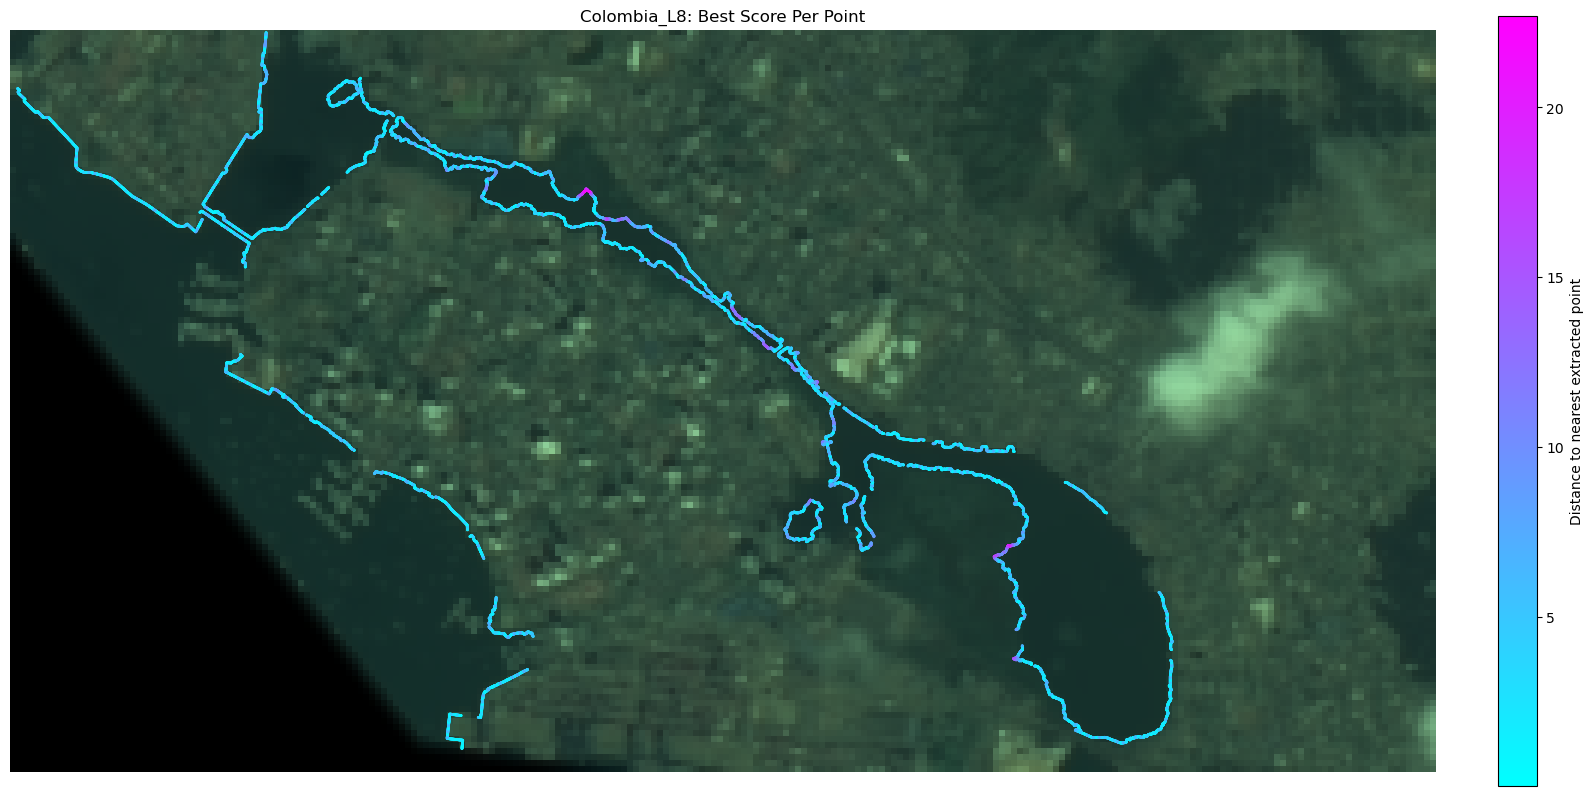

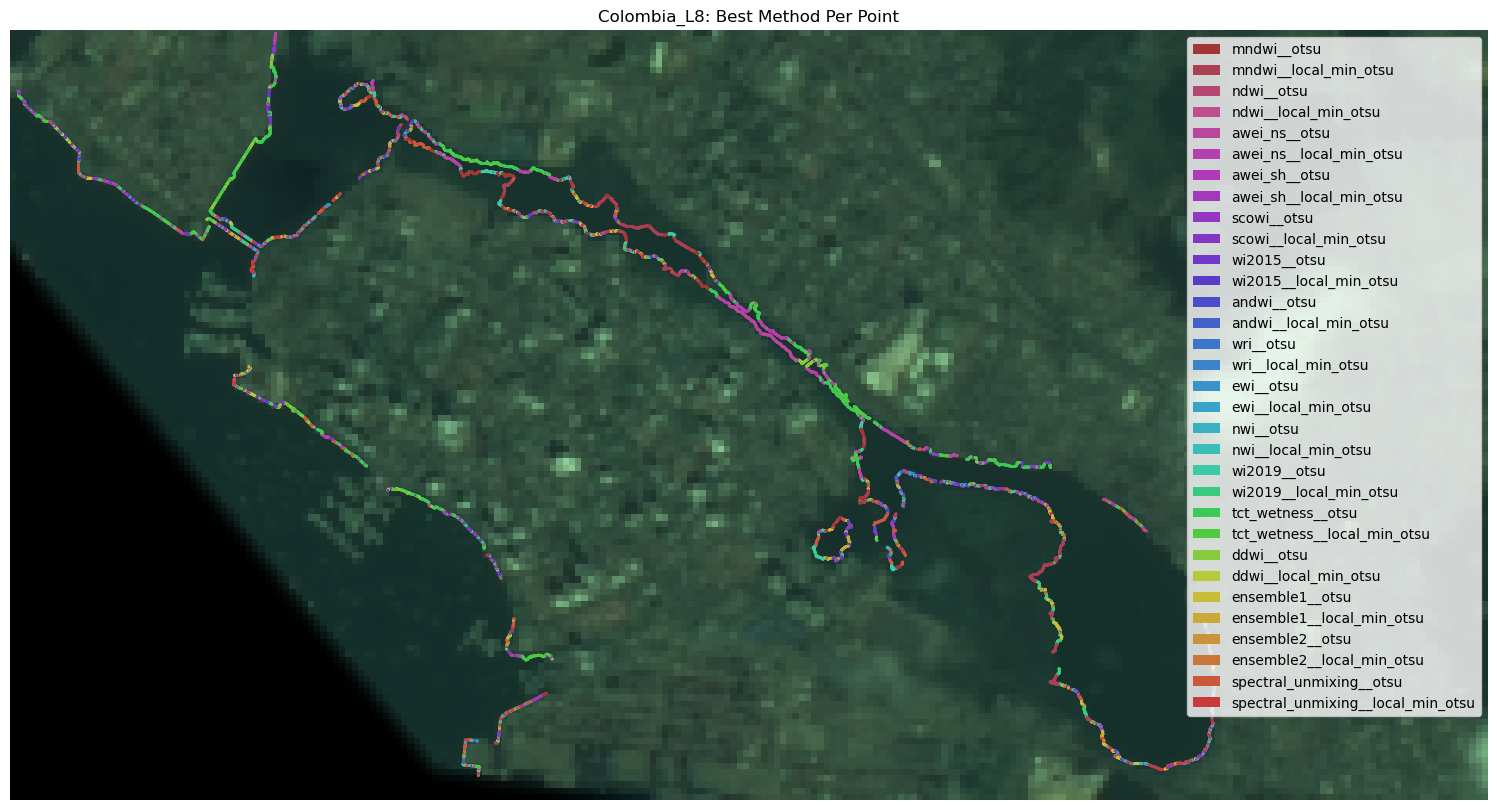

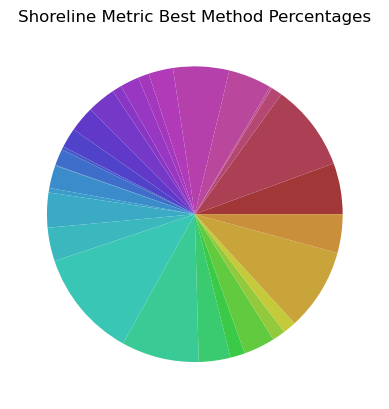

In [105]:
fig = wvep.plot_best_score_per_point(sl_values, ref_sl_points_pxl, sim_bands[:,:,[2, 1, 0]], sitename, sim_sat)
fig = wvep.plot_best_method_per_point(best_per_point_idx, methods, ref_sl_points_pxl, sim_bands[:,:,[2, 1, 0]], sitename, sim_sat)
fig = wvep.plot_best_method_counts(best_per_point_idx, methods, "Shoreline Metric Best Method Percentages", pie_instead=True)

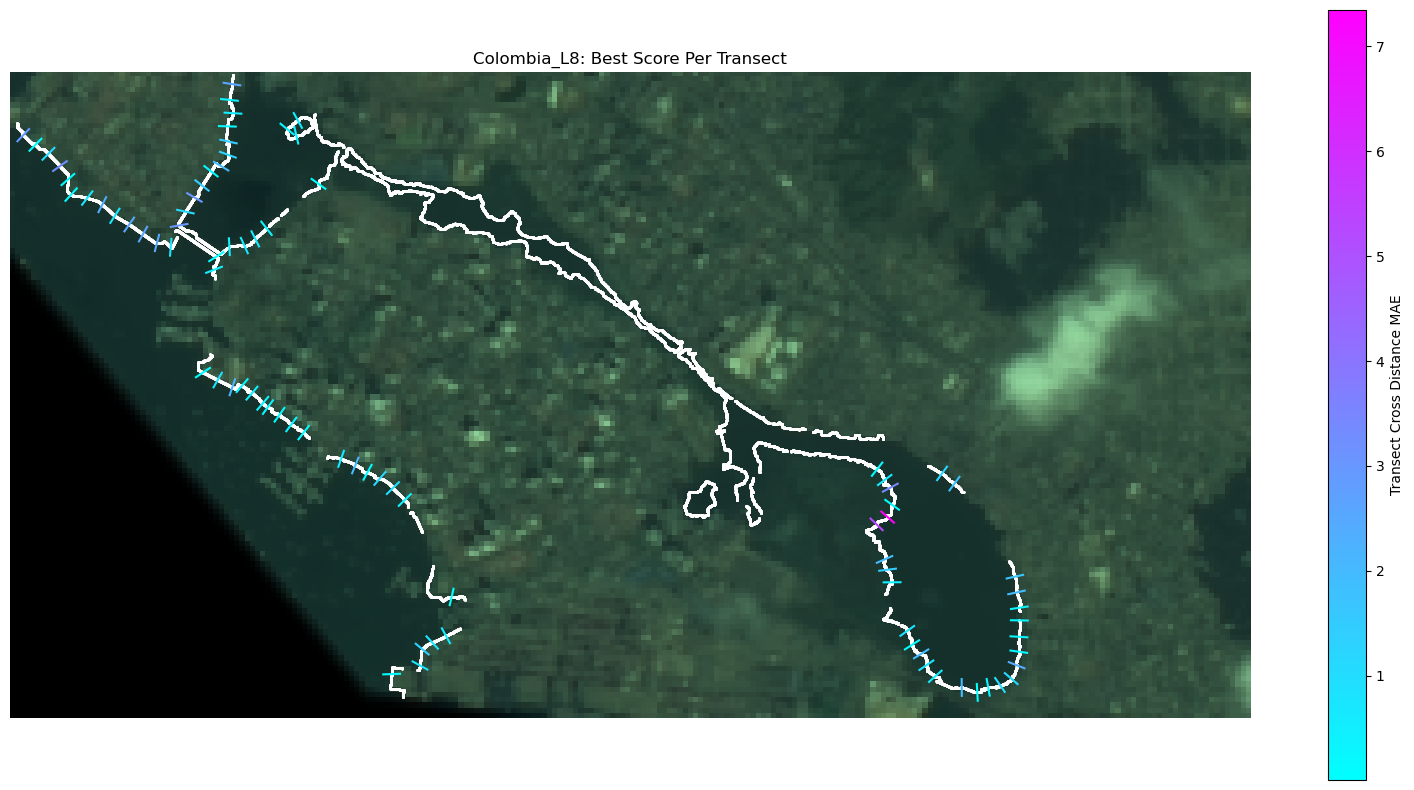

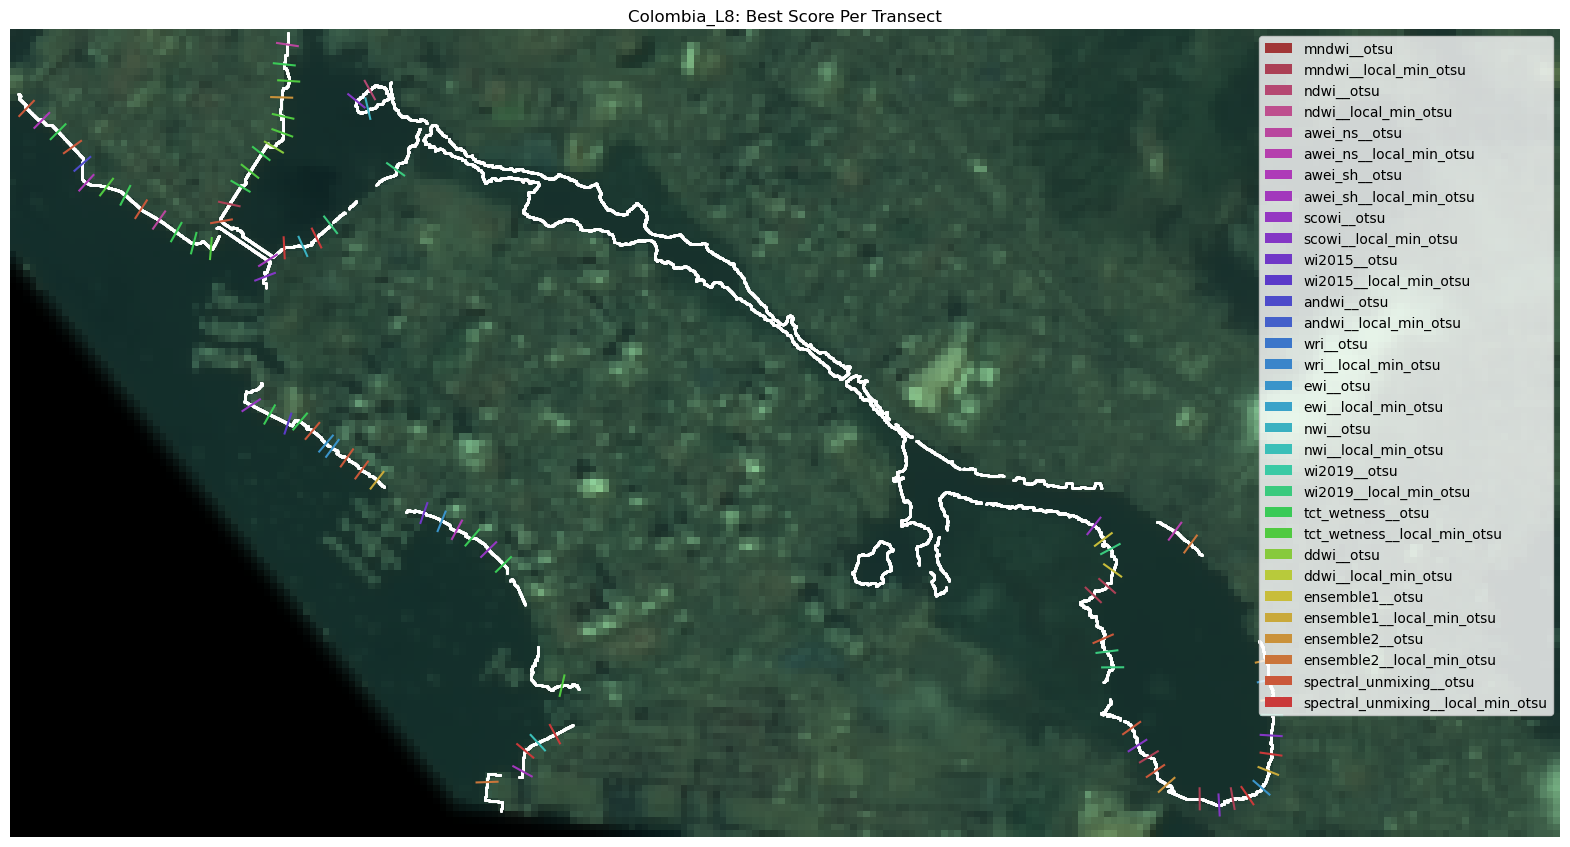

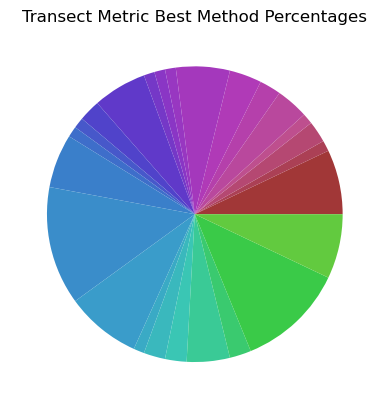

In [106]:
fig = wvep.plot_best_score_per_transect(t_values, transects_pix, ref_sl_points_pxl, sim_bands[:,:,[2, 1, 0]], sitename, sim_sat)
fig = wvep.plot_best_method_per_transect(best_per_transect_idx, methods, transects_pix, ref_sl_points_pxl, sim_bands[:,:,[2, 1, 0]], sitename, sim_sat)
fig = wvep.plot_best_method_counts(best_per_transect_idx, methods, "Transect Metric Best Method Percentages", pie_instead=True)

## Boxplots

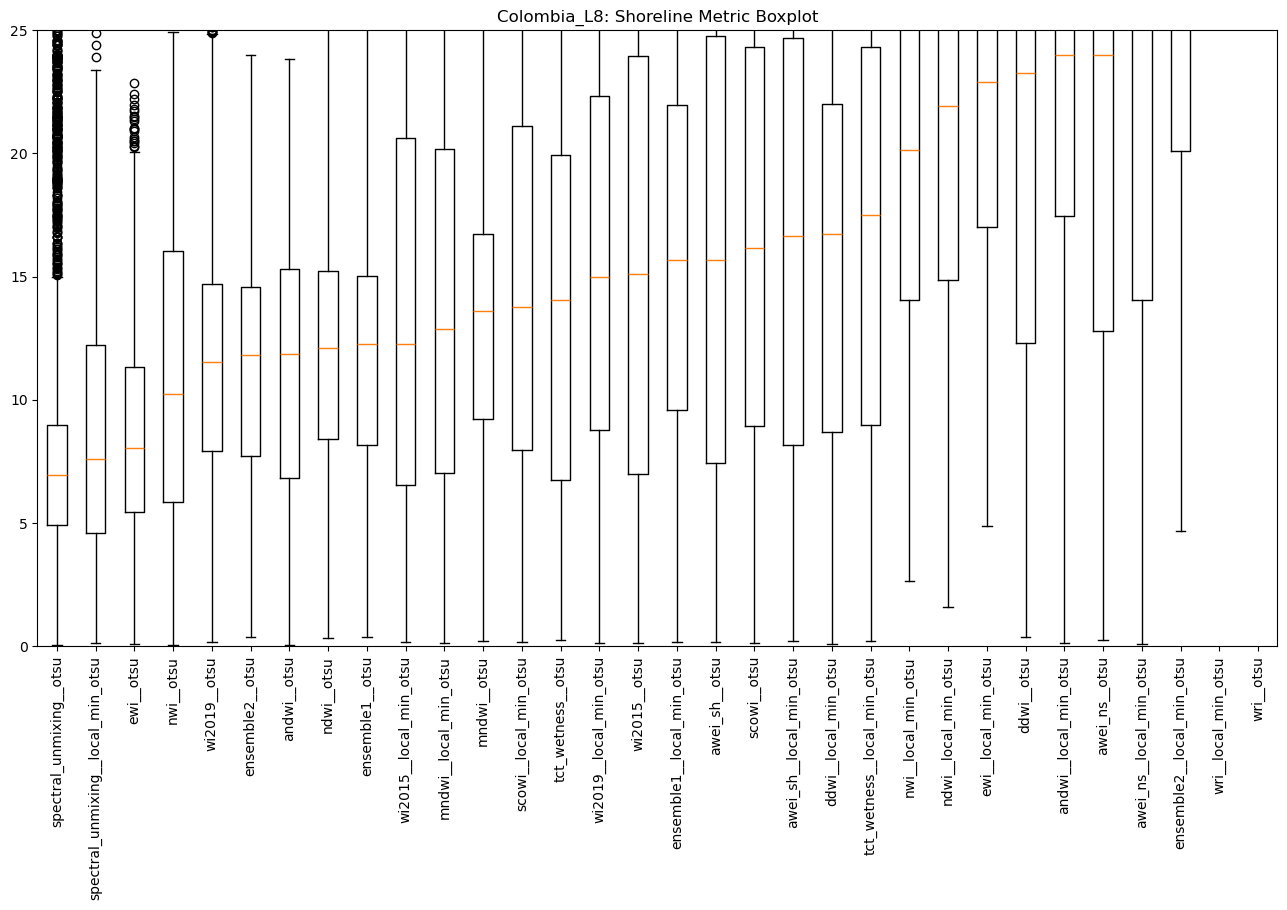

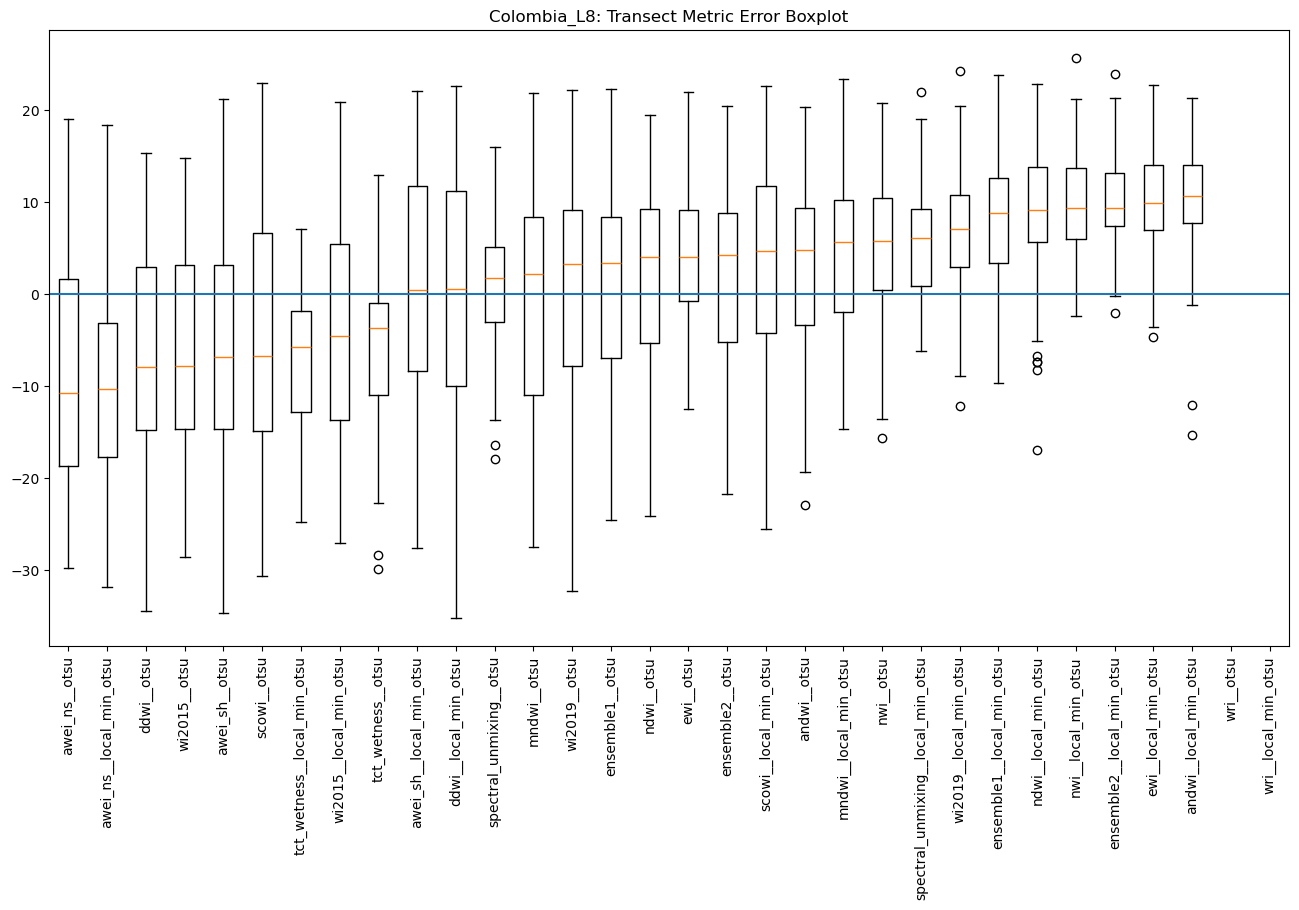

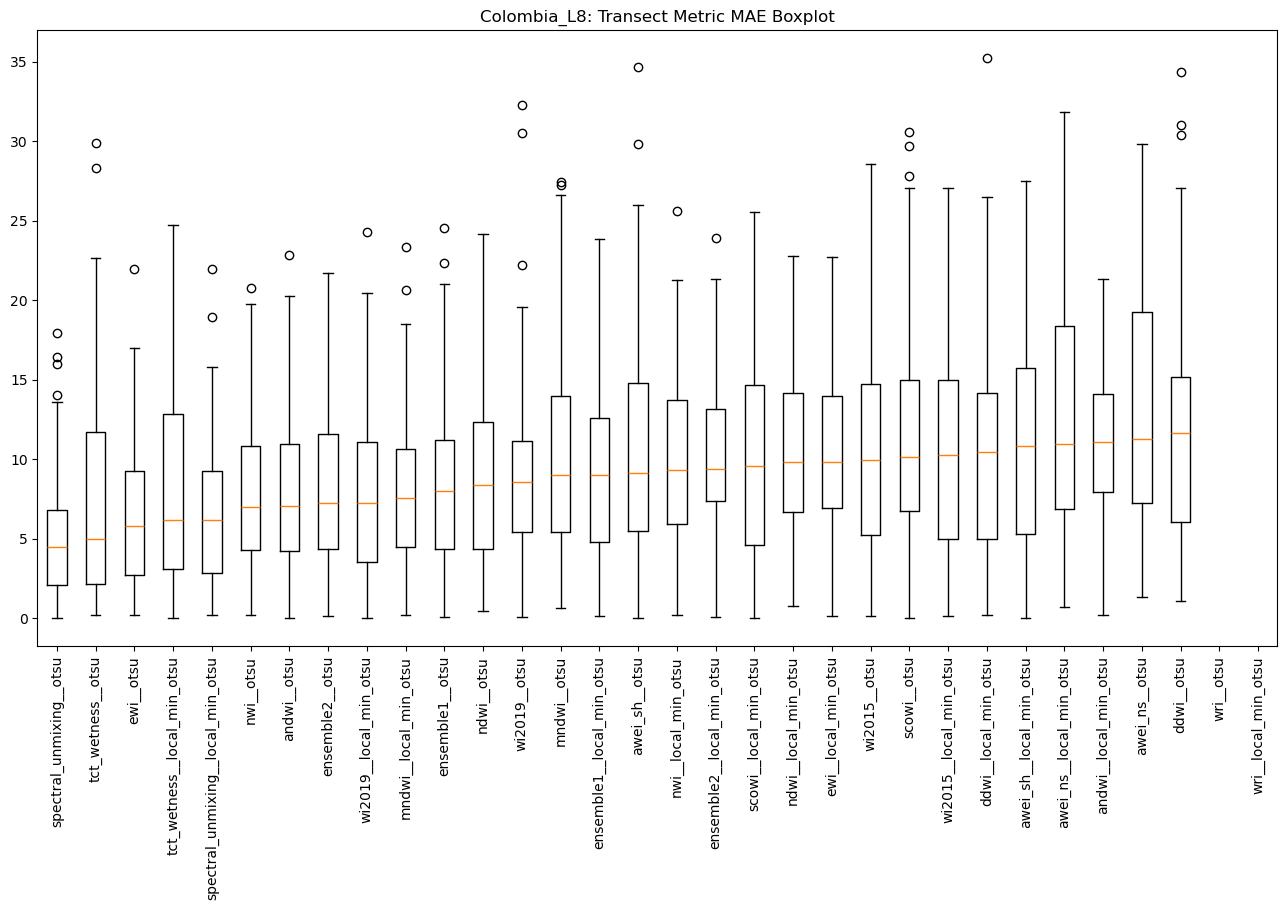

In [130]:
title = f"{sitename}_{sim_sat}: Shoreline Metric Boxplot"
fig, ax = wvep.violin_plots(shoreline_metric, methods, title, ylim=(0, 25), outlier_idx=outlier_idx, box_instead=True, sort_methods=True)
title = f"{sitename}_{sim_sat}: Transect Metric Error Boxplot"
fig, ax = wvep.violin_plots(transect_metric, methods, title, box_instead=True, sort_methods=True)
ax.axhline(0)
title = f"{sitename}_{sim_sat}: Transect Metric MAE Boxplot"
fig, ax = wvep.violin_plots(np.abs(transect_metric), methods, title, box_instead=True, sort_methods=True)

## Comparing Local Extraction Methods

Seems like basically noise, except for notable improvements on difficult areas (visible in improved sl_mean_all, sl_std, and n_outliers).

This is some more shaky evidence that WI are not proficient at representing sub-pixel water contents

WI2015 has some odd behaviour, maybe worth investigating, but for this location the index seems pretty garbage so why bother

Unclear if LSE1 or LSE2 is better

In [42]:
# define hand-partitioned zones
coords_pxl = ref_sl_points_pxl[::100]
zone_indicators = np.zeros((len(coords_pxl)), dtype=int)
zone_indicators[:80] = 0
zone_indicators[80:104] = 1
zone_indicators[104:119] = 2
zone_indicators[119:141] = 1
zone_indicators[141:146] = 2
zone_indicators[146:163] = 3
zone_indicators[163:189] = 4
zone_indicators[189:216] = 5
zone_indicators[216:221] = 2
zone_indicators[221:] = 6

shoreline_metric, transect_metric, methods, info = wv_eval.evaluate_methods(
    index_functions, threshold_functions, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs
)

lse1_shoreline_metric, lse1_transect_metric, methods, info = wv_eval.evaluate_methods(
    index_functions, threshold_functions, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs, lse1=True
)

lse2_shoreline_metric, lse2_transect_metric, methods, info = wv_eval.evaluate_methods(
    index_functions, threshold_functions, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs, lse2=True
)

lse_sanity_shoreline_metric, lse_sanity_transect_metric, methods, info = wv_eval.evaluate_methods(
    index_functions, threshold_functions, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs, lse2=True, zones=zone_indicators
)

entries, outlier_idx = wv_eval.organize_metrics(shoreline_metric, transect_metric, methods)
lse1_entries, _ = wv_eval.organize_metrics(lse1_shoreline_metric, lse1_transect_metric, methods, outlier_idx)
lse2_entries, _ = wv_eval.organize_metrics(lse2_shoreline_metric, lse2_transect_metric, methods, outlier_idx)
lse_sanity_entries, _ = wv_eval.organize_metrics(lse_sanity_shoreline_metric, lse_sanity_transect_metric, methods, outlier_idx)

30it [00:11,  2.53it/s]
30it [00:30,  1.03s/it]
30it [00:13,  2.15it/s]
30it [00:12,  2.32it/s]


['sl_mean', 'sl_mean_all', 'sl_std', 'sl_n_outliers', 't_mean', 't_std', 't_mae']


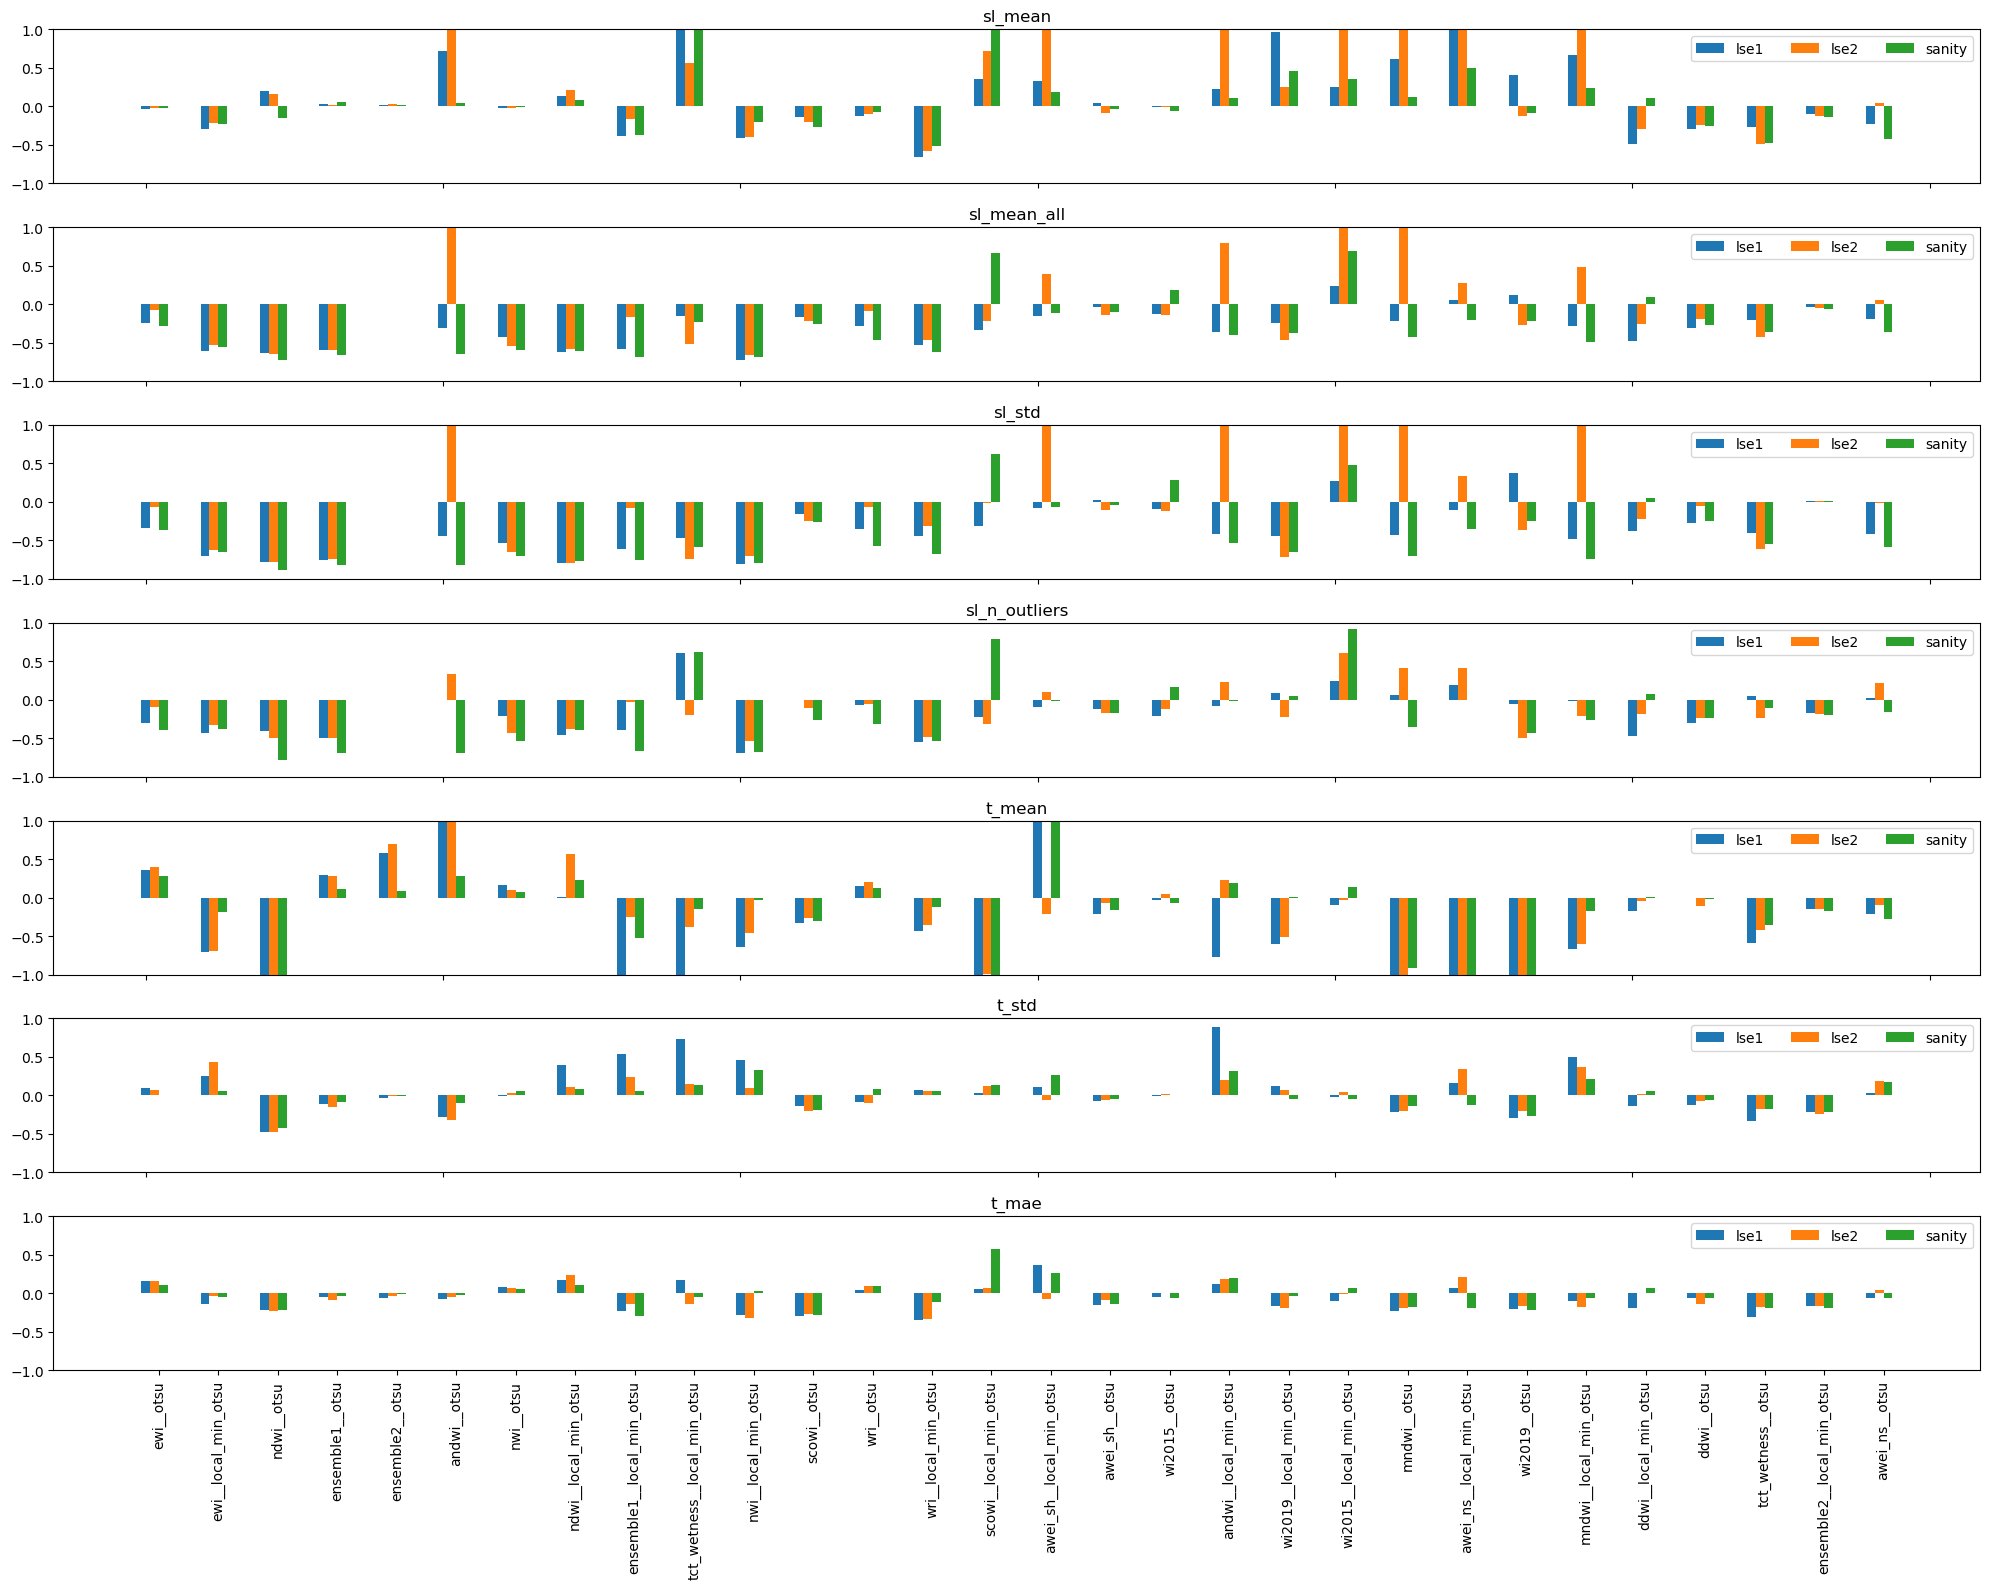

In [43]:
entries_arr = [entries, lse1_entries, lse2_entries, lse_sanity_entries]
titles = ["none", "lse1", "lse2", "sanity"]
fig = wvep.plot_comparison_barplot(entries_arr, titles)

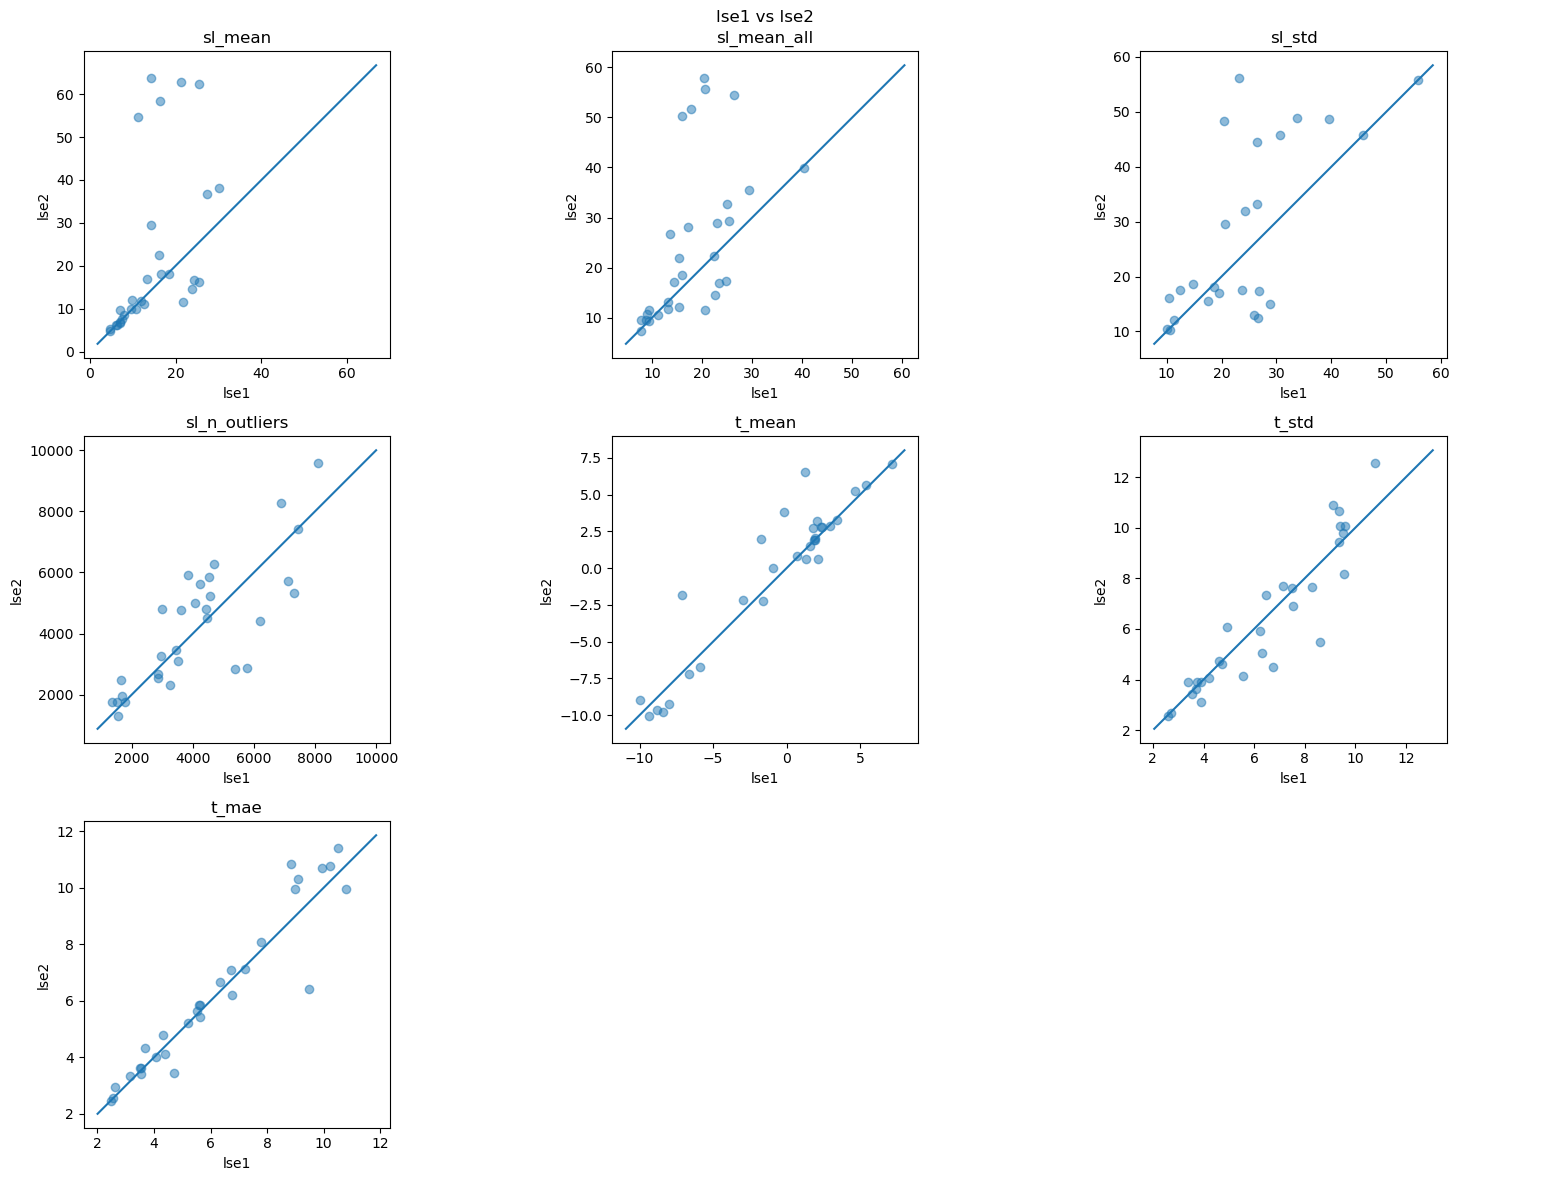

In [44]:
metrics = list(entries[0].keys())[1:]
fig = wvep.plot_comparison(lse1_entries, lse2_entries, "lse1", "lse2", metrics, sl_lim=100)

## Optimal Thresholding

Gives small improvement, therefore thresholding methods seem pretty decent. Optimal threshold changes if ignoring/including outliers. This implies that the optimal threshold changes depending on the part of the image (support for a local thresholding methodology, at least for when there's difficult areas in a subsection of an image). Should refactor so isn't running every index twice (or just remove a thresholding method). Note that ensemble2 results differ as the threshold is applied to each index before binarizing and summing together

How much of improvement is overfitting to noise vs actually improving the index selection. I.e., is the improvement evidence of WI representing sub-pixel water contents (Note that if an optimal threshold was selected for every reference shoreline point, the extracted shoreline would match it perfectly)

In addition, noisier shorelines are inadvertently encouraged due to the flaw of the shoreline metric (t_mae gets worse)

(why are some sl_mean worse? is this a threshold resolution issue?)

In [36]:
# run with regular threshold_functions to get consistent outlier_idx
shoreline_metric, transect_metric, methods, info = wv_eval.evaluate_methods(
    index_functions, threshold_functions, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs
)
entries, outlier_idx = wv_eval.organize_metrics(shoreline_metric, transect_metric, methods)

# run experiment
threshold_functions_temp = [otsu]
opt_shoreline_metric, opt_transect_metric, methods, opt_info = wv_eval.evaluate_methods(
    index_functions, threshold_functions_temp, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs, optimal_thresholds=True
)
shoreline_metric, transect_metric, methods, info = wv_eval.evaluate_methods(
    index_functions, threshold_functions_temp, sim_bands, ref_sl_points, transects, collider_settings, sds_data, ensemble_idx_funcs
)

# use outlier idx from run with all threshold functions for uniformity
entries, _ = wv_eval.organize_metrics(shoreline_metric, transect_metric, methods, outlier_idx)
opt_entries, _ = wv_eval.organize_metrics(opt_shoreline_metric, opt_transect_metric, methods, outlier_idx)

30it [00:11,  2.55it/s]
15it [16:28, 65.87s/it]
15it [00:07,  1.95it/s]


In [37]:
wv_eval.print_metrics(opt_entries, "sl_mean")
print("\n")
wv_eval.print_metrics(entries, "sl_mean")

                                    sl_mean      sl_mean_all  sl_std       sl_outlier     t_mean       t_std        t_mae       
ensemble1__otsu:                    5.423        6.232        7.161        706            -2.809       6.700        4.866       
andwi__otsu:                        5.773        6.562        8.151        796            -2.945       6.634        4.860       
nwi__otsu:                          5.969        6.590        8.273        885            -2.773       5.844        4.612       
ensemble2__otsu:                    6.346        6.385        6.772        572            -3.212       6.047        4.758       
ewi__otsu:                          6.368        6.985        8.612        909            -3.622       5.362        4.802       
awei_ns__otsu:                      7.024        7.486        6.566        667            -2.038       6.685        5.238       
awei_sh__otsu:                      7.198        9.977        11.714       1884           -3.574 

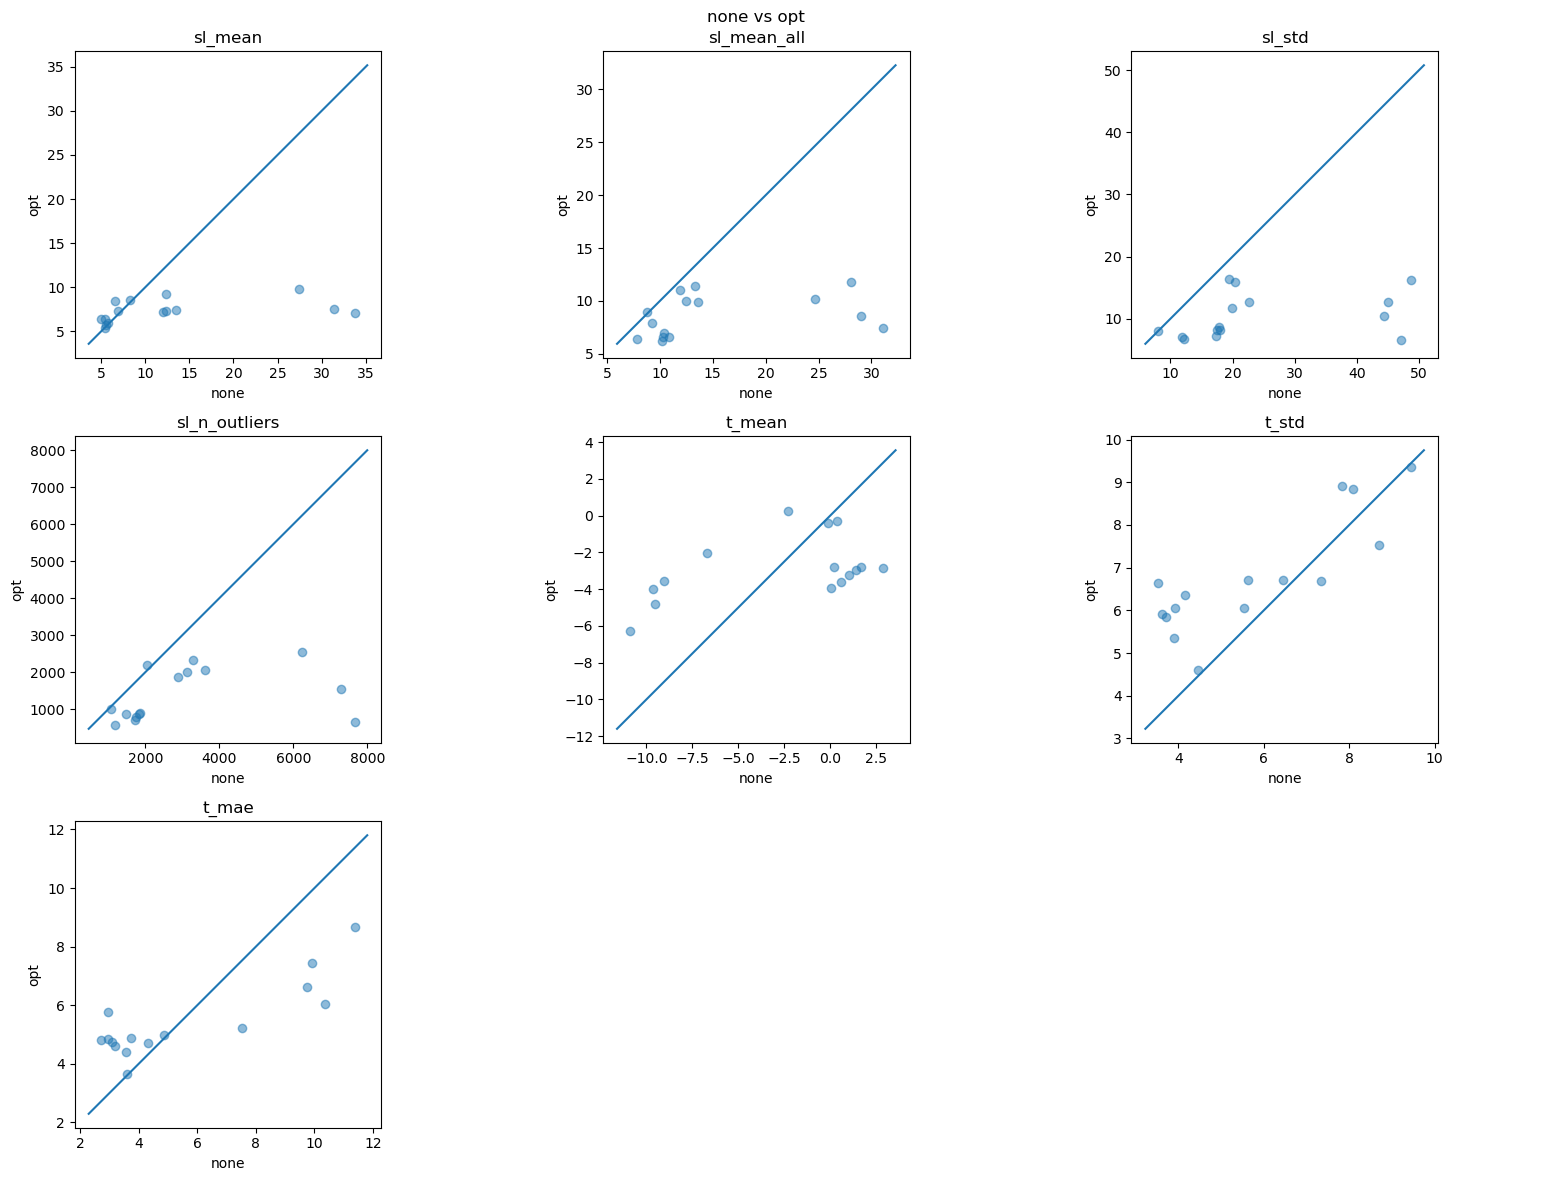

In [39]:
metrics = list(entries[0].keys())[1:]
fig = wvep.plot_comparison(entries, opt_entries, "none", "opt", metrics, sl_lim=100)

### Optimizing entire shoreline, or omitting outlier

In [ ]:
im_ind = andwi(sim_bands.reshape(-1, sim_bands.shape[-1]))

In [ ]:
ignore_outliers_contours, ignore_outliers_threshold = wv_eval.get_optimal_threshold(im_ind.reshape(sim_bands.shape[:-1]), ref_sl_points, sds_data, outlier_idx=outlier_idx)
ignore_outliers_dists = m.get_nearest_distance(ref_sl_points, ignore_outliers_contours)
print(np.mean(ignore_outliers_dists))
print(np.mean(ignore_outliers_dists[~outlier_idx]))

9.688412532249526
5.045890616986989


In [35]:
inc_outliers_contours, inc_outliers_threshold = wv_eval.get_optimal_threshold(im_ind.reshape(sim_bands.shape[:-1]), ref_sl_points, sds_data)
inc_outliers_dists = m.get_nearest_distance(ref_sl_points, inc_outliers_contours)
print(np.mean(inc_outliers_dists))
print(np.mean(inc_outliers_dists[~outlier_idx]))

6.561689806491867
5.773254337348431


## Custom Spectral Unmixing

otsu_thresh = np.float32(0.3052596)
sl_mean: 7.847595695026948, 29.59797188418264
t_mae: 5.215205161506526


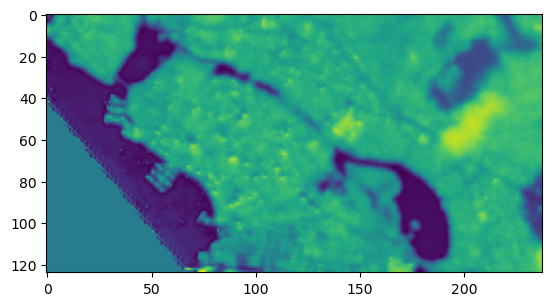

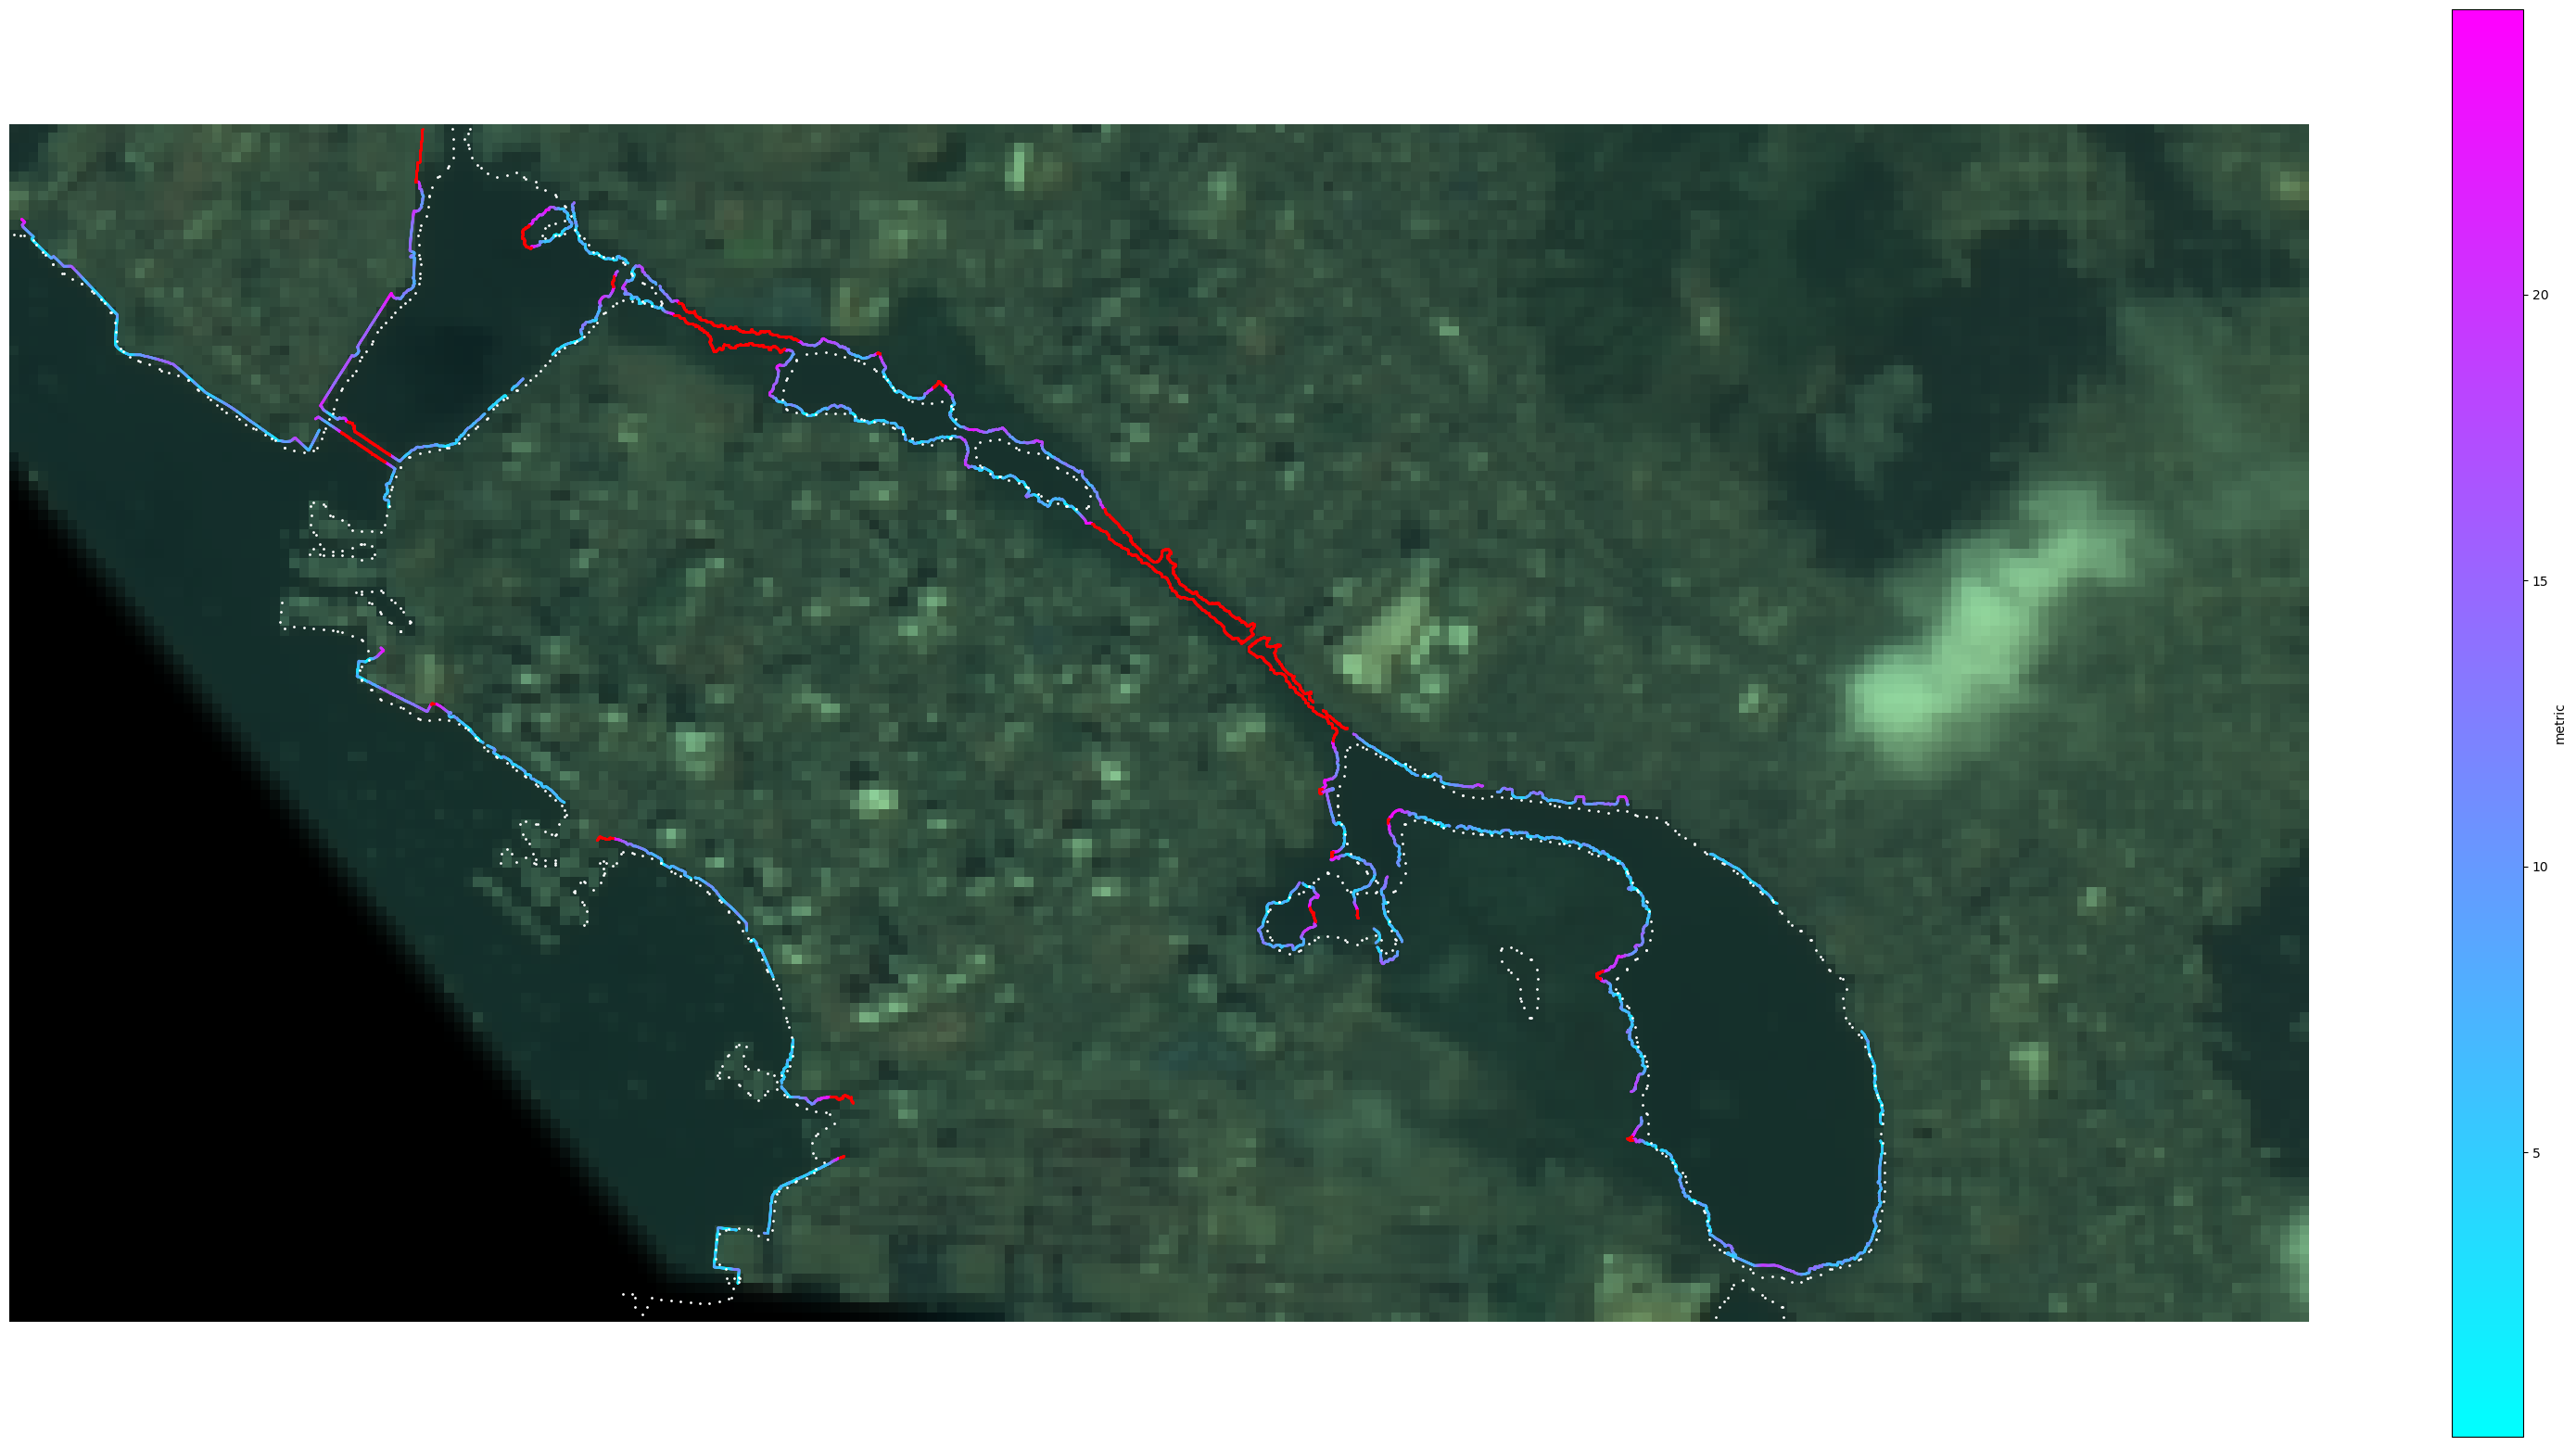

In [ ]:
im_ind = ensemble2(sim_bands, ensemble_idx_funcs, otsu, cloud_mask, sds_data["sl_buffer"])
# im_ind = ndwi(sim_bands.reshape(-1, sim_bands.shape[-1])).reshape(sim_bands.shape[:-1])
percentages = su.spectral_unmixing_1(sim_bands, im_ind, sds_data)
plt.imshow(percentages.reshape(sim_bands.shape[:-1]))

otsu_thresh = otsu(percentages, cloud_mask, sds_data["sl_buffer"])
contours = wv_eval.get_contours(percentages.reshape(sim_bands.shape[:-1]), otsu_thresh, sds_data)
sl_dists = m.get_nearest_distance(ref_sl_points, contours)
t_dists, _ = m.get_median_distances(transects, ref_sl_points, contours, collider_settings)

print(f"{otsu_thresh = }")
print(f"sl_mean: {np.mean(sl_dists[~outlier_idx])}, {np.mean(sl_dists)}")
print(f"t_mae: {np.nanmean(np.abs(t_dists))}")
contour_pxl = SDS_tools.convert_world2pix(contours, georef)
fig = wvep.plot_shoreline_metric(sl_dists, (0, 25), ref_sl_points_pxl, sim_bands[:,:,[2, 1, 0]], contours_pxl=contour_pxl)

## Combinations of Note

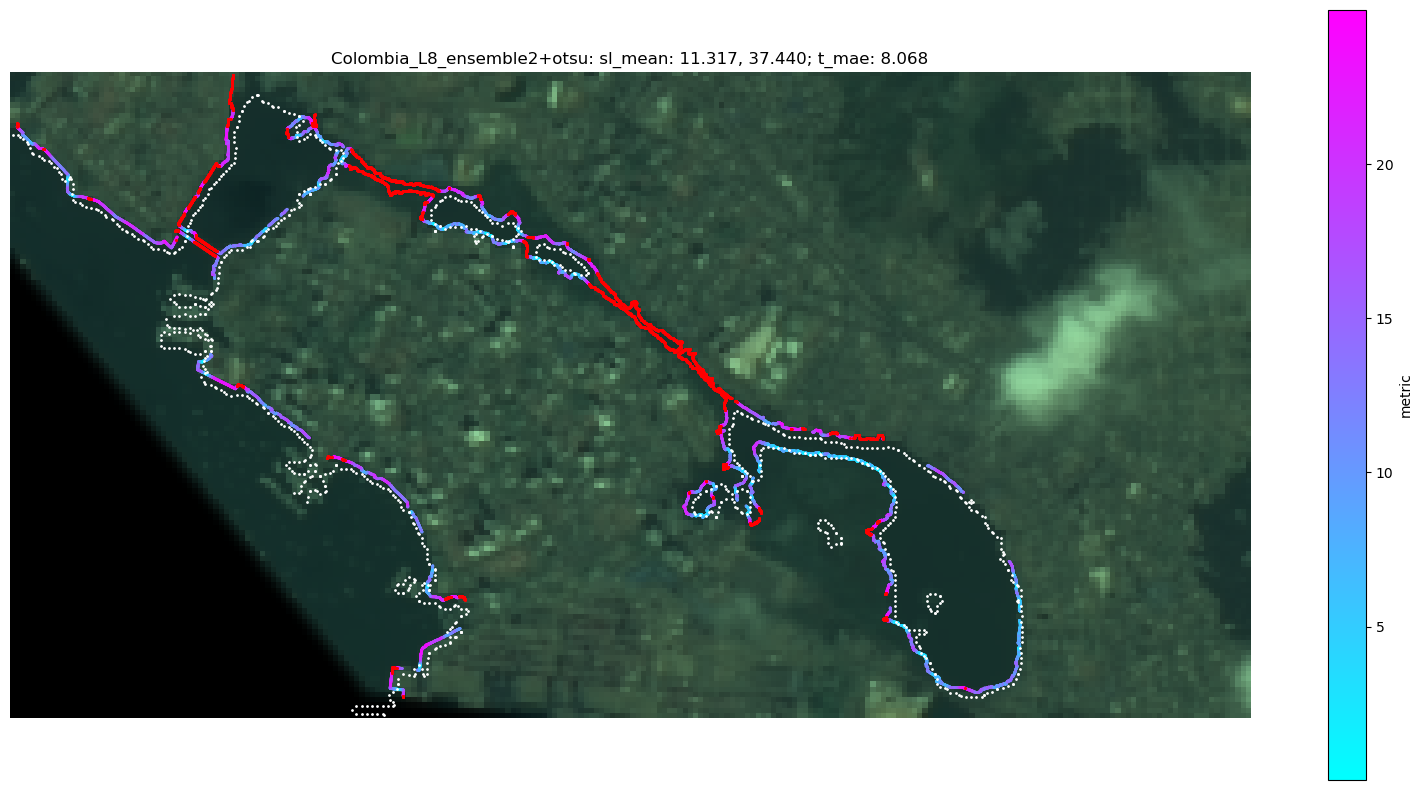

In [40]:
def plot_method(index, threshold, method):
    contours = wv_eval.get_contours(index.reshape(sim_bands.shape[:-1]), threshold, sds_data)
    sl_dists = m.get_nearest_distance(ref_sl_points, contours)
    t_dists, _ = m.get_median_distances(transects, ref_sl_points, contours, collider_settings)

    contour_pxl = SDS_tools.convert_world2pix(contours, georef)
    title = sitename + "_" + sim_sat + "_" + method + f": sl_mean: {np.mean(sl_dists[~outlier_idx]):.3f}, {np.mean(sl_dists):.3f}; t_mae: {np.nanmean(np.abs(t_dists)):.3f}"
    return wvep.plot_shoreline_metric(sl_dists, (0, 25), ref_sl_points_pxl, sim_bands[:,:,[2, 1, 0]], title, contours_pxl=contour_pxl)

# Ensemble2 + Otsu
index = ensemble2(sim_bands, ensemble_idx_funcs, otsu, cloud_mask, sds_data["sl_buffer"])
threshold = otsu(index, cloud_mask, sds_data["sl_buffer"])
method = "ensemble2+otsu"
fig = plot_method(index, threshold, method)

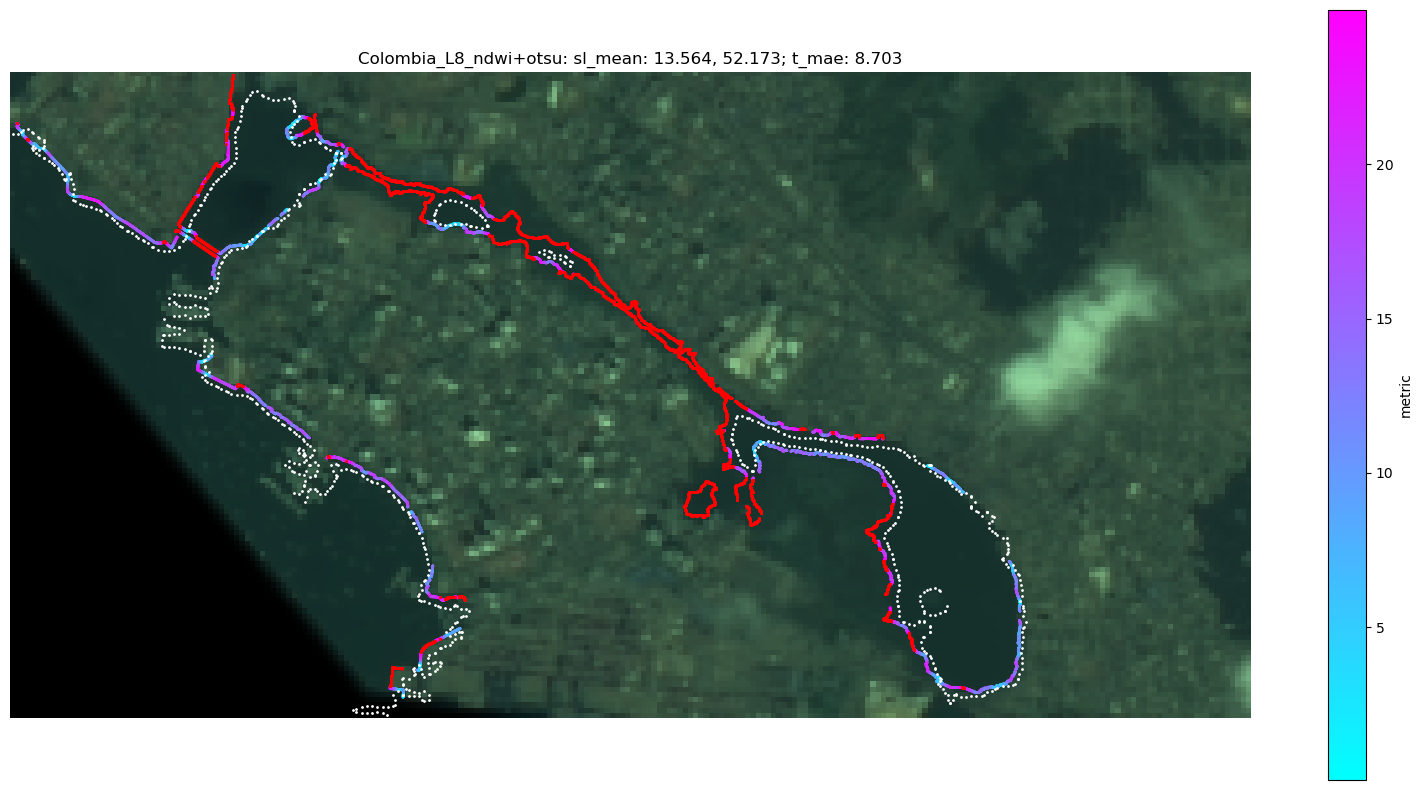

In [41]:
# ndwi + otsu (good at simpler areas with transects, significantly worse at harder areas)
index = ndwi(sim_bands.reshape(-1, sim_bands.shape[-1]))
threshold = otsu(index, cloud_mask, sds_data["sl_buffer"])
method = "ndwi+otsu"
fig = plot_method(index, threshold, method)

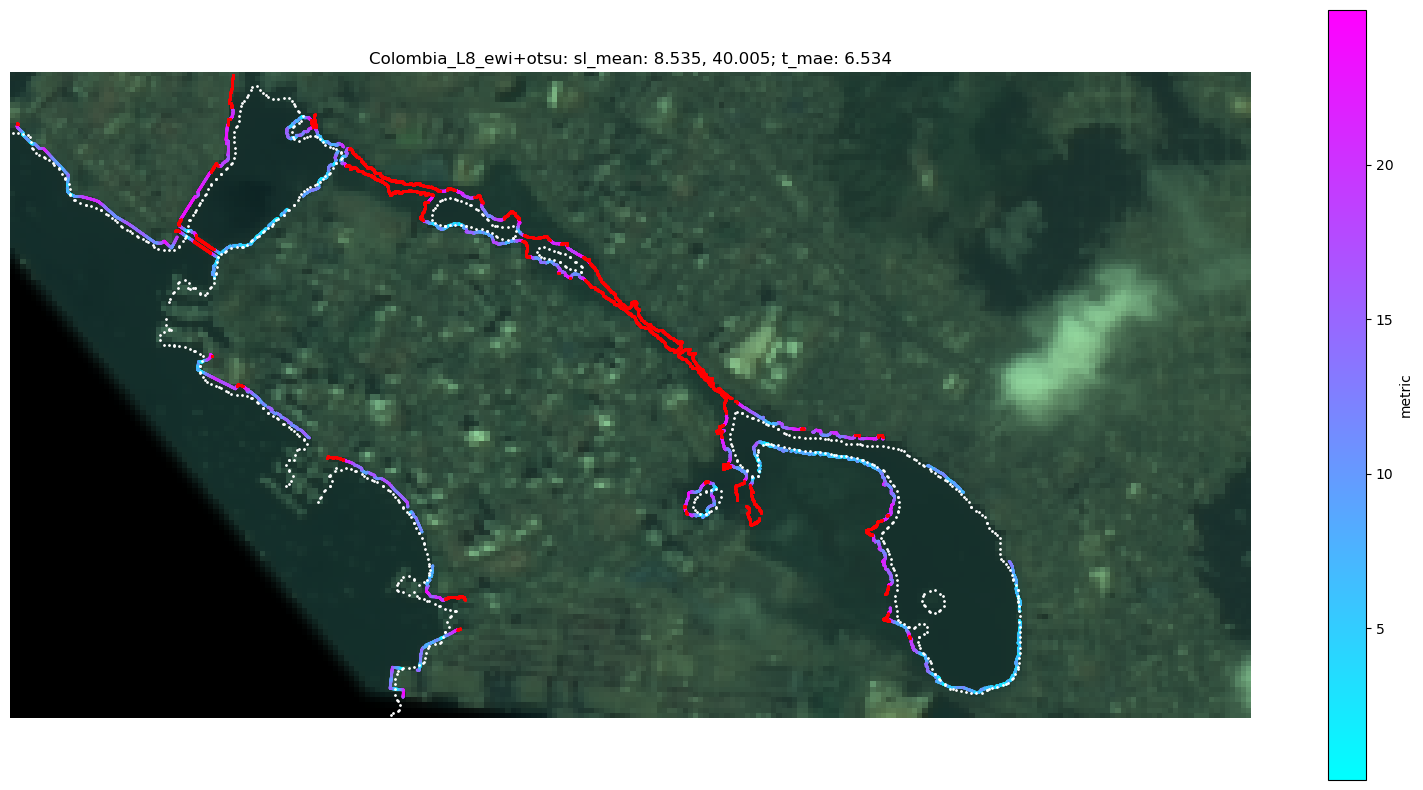

In [42]:
# ewi + otsu (second best)
index = ewi(sim_bands.reshape(-1, sim_bands.shape[-1]))
threshold = otsu(index, cloud_mask, sds_data["sl_buffer"])
method = "ewi+otsu"
fig = plot_method(index, threshold, method)

In [47]:
im_ind = ensemble2(sim_bands, ensemble_idx_funcs, otsu, cloud_mask, sds_data["sl_buffer"])
percentages = su.spectral_unmixing_1(sim_bands, im_ind, sds_data)
otsu_thresh = otsu(percentages, cloud_mask, sds_data["sl_buffer"])
method = "spectral_unmixing+otsu"
fig = plot_method(index, threshold, method)

# contours = wv_eval.get_contours(percentages.reshape(sim_bands.shape[:-1]), otsu_thresh, sds_data)
# sl_dists = m.get_nearest_distance(ref_sl_points, contours)
# t_dists, _ = m.get_median_distances(transects, ref_sl_points, contours, collider_settings)

# print(f"{otsu_thresh = }")
# print(f"sl_mean: {np.mean(sl_dists[~outlier_idx])}, {np.mean(sl_dists)}")
# print(f"t_mae: {np.nanmean(np.abs(t_dists))}")
# contour_pxl = SDS_tools.convert_world2pix(contours, georef)
# fig = wvep.plot_shoreline_metric(sl_dists, (0, 25), ref_sl_points_pxl, sim_bands[:,:,[2, 1, 0]], contours_pxl=contour_pxl)

ValueError: cannot reshape array of size 29512 into shape (165,317)